# MGB-SA hydrology — from rainfall to discharge (one URH)

**Project**: suspended sediment transport in the Magdalena basin with MGB-SED.
Before sediments, MGB must reproduce **discharge** (river flow). This notebook builds, from scratch and in simple
Python, the two stages of MGB-SA hydrology on a **single URH**:

1. the **vertical water balance** — how rain splits into evapotranspiration, surface runoff, interflow and baseflow;
2. **routing** — how those components become a discharge **hydrograph** (explained; channel routing is done by the plugin).

It explains *what the model does*; it is a teaching model, not the MGB solver.

> **Status — dated note, 2026-08-19. This notebook is load-bearing, not decorative.** The production water balance
> `src/mgb_hydrology.py` states in its own docstring that it is *"a vectorised, importable implementation of the daily
> rainfall-runoff formulation derived by this project itself in `notebooks/03_hydrology.ipynb` (sections 1-5)"*, and it
> labels its default ET branch *"nb03 s.1 verbatim"* and its runoff block *"nb03 s.2, verbatim"*. Cell 7 below is
> transcribed verbatim into `src/test_mgb_hydrology.py::test_07_notebook03_regression`, which asserts the engine
> reproduces it to **1e-12** — so the `peak Q: 11.33 mm/day` and `baseflow share at day 120: 98.9 %` printed below are
> **asserted by the test suite** (154 tests pass, 2026-08-19), not merely stored. Read this notebook as the project's
> own derivation, not as an exercise.
>
> **Two sections were overtaken by the implementation they seeded, and are corrected in place below:** §3 (the
> reservoir is discretised differently in cell 7 than the prose writes) and §5 (channel routing is **not** left to the
> plugin — the engine routes in Python, and `celerity` is a calibrated parameter). The **adopted** configuration is
> **H2E** — v2 gauge-only forcing, FAO-56 ET with `theta_crit = 0.6`, revised objective — scoring **F = 0.25931** over
> 2009-2018 on **63 gauges** (`docs/26_phase3_refit.md` and its 2026-08-10 addendum).

**Glossary**: *discharge* = river flow rate; *hydrograph* = discharge vs time; *saturated* = soil full of water;
*runoff* = water reaching the stream; *baseflow* = slow groundwater contribution; *recession* = the drying-out decline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. The soil water balance

Each day, one URH holds a soil water amount $W$ (mm), capped at $W_m$. The balance is "in minus out":

$$W_{t+1} = W_t + P - ET - D_{sup} - D_{int} - D_{bas}$$

- $P$ — precipitation reaching the soil (after canopy interception)
- $ET$ — evapotranspiration (evaporation + plant transpiration), here limited by soil moisture: $ET = ET_p \cdot (W/W_m)$
- $D_{sup}$ — **surface runoff** (fast, hours) → makes the hydrograph peak
- $D_{int}$ — **interflow** through shallow soil (medium, days)
- $D_{bas}$ — **baseflow** from groundwater (slow, weeks-months) → sustains dry-season flow

> **What the adopted model actually runs (dated note, 2026-08-19).** The `ET = ETp·(W/Wm)` form above is the engine's
> `et_stress='linear'` branch, and it is still the **code default** — deliberately, because every archived run (nb13,
> nb14, `sim_baseline*`, `sim_calibrated*`) was produced with it and changing the default would silently break
> comparability with everything on record. But the **adopted H2E calibration does not use it.** H2E runs
> `et_stress='fao56'`: ET stays at the potential rate until `W/Wm` falls below `theta_crit = 0.6`, and only then
> declines linearly to zero — with `kc_mult = 1.66247` (`data/processed/sim_calibrated_v2/parameters_H2E.csv`;
> `src/report_h2e.py` asserts `ET_STRESS == 'fao56'` and `THETA_CRIT == 0.6` before it will reproduce the fit).
> **Why the change was needed:** the linear form throttles ET even in moist soil, so the earlier refits compensated by
> railing `kc_mult` at ~2 — beyond any FAO-56 crop coefficient (`docs/26_phase3_refit.md` §5.1). Under FAO-56,
> `kc_mult` came off its rail at no cost in `F` (`docs/29_seed_expansion.md`), which is why H2E is the adopted cell.
> One further gap: the **canopy interception** named in the `P` bullet above is never coded here; the engine adds it
> as an `alpha·LAI` bucket.


## 2. Surface runoff: variable contributing area

Runoff here is **saturation-excess**: it happens because the soil is full, not because rain is intense.
And the area does not saturate all at once — only a **fraction** $A_{sat}$ is saturated at a given wetness, growing as
the soil wets up:

$$A_{sat} = 1 - \left(1 - \frac{W}{W_m}\right)^{b}$$

The parameter $b$ controls how fast that fraction grows (soil heterogeneity). Surface runoff is the share of rain
falling on the saturated fraction: $D_{sup} = P \cdot A_{sat}$.


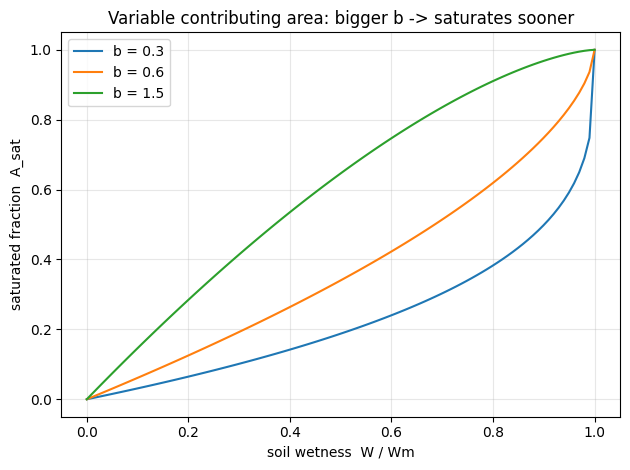

In [2]:
W_over_Wm = np.linspace(0, 1, 100)
for b_val in [0.3, 0.6, 1.5]:
    plt.plot(W_over_Wm, 1-(1-W_over_Wm)**b_val, label=f"b = {b_val}")
plt.xlabel("soil wetness  W / Wm"); plt.ylabel("saturated fraction  A_sat")
plt.title("Variable contributing area: bigger b -> saturates sooner")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 3. The three exits and the linear reservoir (recession)

Water that infiltrates does not vanish; it drains slowly to the stream through **linear reservoirs** — stores whose
outflow is proportional to what they hold, giving an exponential decline:

$$Q(t) = Q_0\, e^{-t/K}$$

- surface store: tiny $K_{sup}$ (~1 day) — fast peak
- interflow store: medium $K_{int}$ (days)
- baseflow store: large $K_{bas}$ (weeks) — the slow **recession** that keeps the river alive in the dry season

Big $K_{bas}$ = slow release = flow survives long droughts; small $K_{bas}$ = the river dries up fast.

> **Two corrections, dated 2026-08-19.**
>
> **(a) The prose above and the code in cell 7 are not the same scheme.** This section writes the analytic recession
> `Q(t) = Q0·exp(−t/K)`; cell 7 codes the **Euler** one-day discretisation `Q = S/K`. They diverge as `K` approaches
> the daily step: the one-day release fraction is `1 − exp(−1/K)` analytically versus `1/K` in cell 7 — at cell 7's own
> `Ksup = 1.0` that is **1.000000 vs 0.632121**, i.e. the Euler form releases ~58 % more on the first day, and it is
> unstable for `K < 1`. The production engine therefore defaults to `reservoir='exact'`
> (`S += inflow; Q = S·(1 − exp(−dt/K)); S -= Q`) and keeps `reservoir='euler'` **only** so that cell 7 can be
> regression-tested (`src/mgb_hydrology.py` §5; `src/test_mgb_hydrology.py::test_07_notebook03_regression`). Cell 7 is
> left exactly as written on purpose — the test pins it.
>
> **(b) The calibrated basin inverts the "tiny Ksup" intuition.** ~~surface store: tiny K_sup (~1 day) — fast peak~~ is
> the teaching expectation; **RETIRED as a description of the fitted basin — shown, not quoted as current.** The adopted
> H2E fit has `k_sup = 19.19933 d`, **railed at its upper bound 20.0**, against `k_bas = 42.97399 d` and
> `k_int = k_int_frac × k_bas = 0.0201416 × 42.97399 = 0.86556 d`, itself **railed at the `k_int_frac` lower bound
> 0.02**. The fitted surface response is therefore **~22× slower than interflow**, not faster. Two railed parameters
> are a statement about the fit, not a tuning success — read `docs/26_phase3_refit.md` §5.1 before quoting any fitted
> parameter (`data/processed/sim_calibrated_v2/parameters_H2E.csv`).


## 4. Full daily simulation

We force one URH with a synthetic rainfall series (a wet spell, then a long dry period) and watch the soil water and
the discharge components. Watch: surface runoff spikes during storms; after the rain stops, discharge declines along a
baseflow-dominated recession.


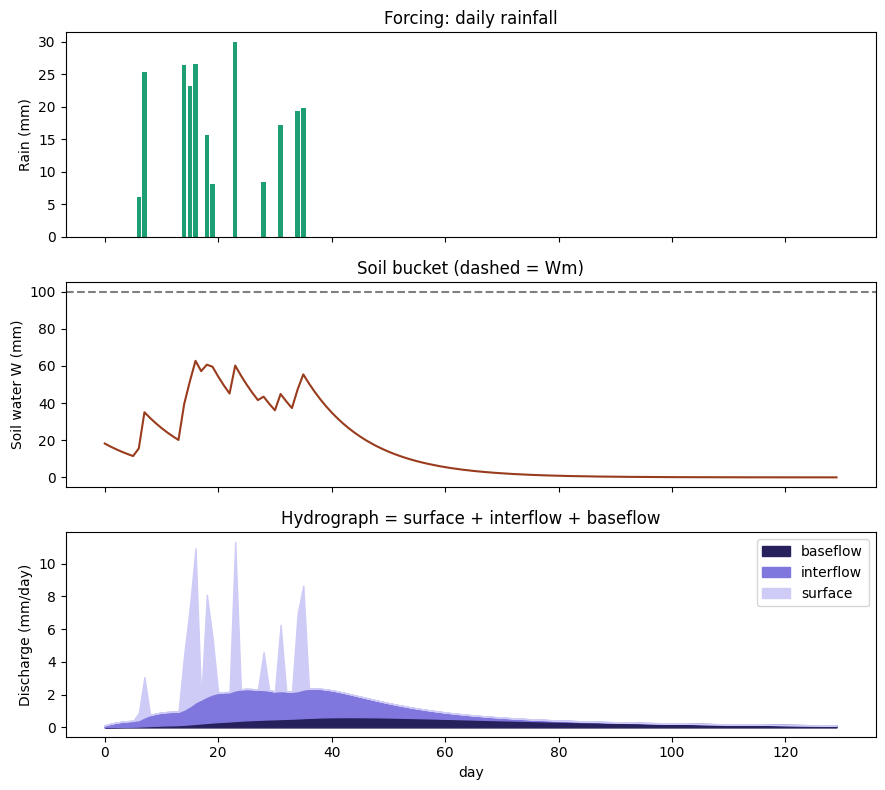

peak Q: 11.33 mm/day
baseflow share at day 120 (dry): 98.9 %


In [3]:
# --- Parameters for ONE URH ---
Wm, b, ETp = 100.0, 0.6, 3.0
adr, fint = 0.06, 0.6            # drainage fraction; interflow share of drainage
Ksup, Kint, Kbas = 1.0, 6.0, 45.0

# --- Synthetic rainfall: wet spell days 5-35, then dry ---
ndays = 130
P = np.zeros(ndays)
rng = np.random.default_rng(0)
for t in range(5, 36):
    if rng.random() < 0.5:
        P[t] = rng.uniform(5, 30)

# --- State + recording ---
W = 20.0; Ssup = Sint = Sbas = 0.0
rec = {k: np.zeros(ndays) for k in ["W","Dsup","Qsup","Qint","Qbas","Q"]}

for t in range(ndays):
    Asat = 1 - (1 - W/Wm)**b
    Dsup = P[t] * Asat
    W += P[t] - Dsup
    if W > Wm:
        Dsup += W - Wm; W = Wm
    W -= ETp * (W/Wm)
    drain = adr * W; W -= drain
    if W < 0: W = 0
    Ssup += Dsup;         Qsup = Ssup/Ksup; Ssup -= Qsup
    Sint += fint*drain;   Qint = Sint/Kint; Sint -= Qint
    Sbas += (1-fint)*drain; Qbas = Sbas/Kbas; Sbas -= Qbas
    Q = Qsup + Qint + Qbas
    for k,v in [("W",W),("Dsup",Dsup),("Qsup",Qsup),("Qint",Qint),("Qbas",Qbas),("Q",Q)]:
        rec[k][t] = v

days = np.arange(ndays)
fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
ax[0].bar(days, P, color="#1D9E75"); ax[0].set_ylabel("Rain (mm)"); ax[0].set_title("Forcing: daily rainfall")
ax[1].plot(days, rec["W"], color="#993C1D"); ax[1].axhline(Wm, ls="--", color="grey")
ax[1].set_ylabel("Soil water W (mm)"); ax[1].set_title("Soil bucket (dashed = Wm)")
ax[2].fill_between(days, 0, rec["Qbas"], label="baseflow", color="#26215C")
ax[2].fill_between(days, rec["Qbas"], rec["Qbas"]+rec["Qint"], label="interflow", color="#7F77DD")
ax[2].fill_between(days, rec["Qbas"]+rec["Qint"], rec["Q"], label="surface", color="#CECBF6")
ax[2].set_ylabel("Discharge (mm/day)"); ax[2].set_xlabel("day")
ax[2].set_title("Hydrograph = surface + interflow + baseflow"); ax[2].legend()
plt.tight_layout(); plt.show()

print("peak Q:", round(rec['Q'].max(),2), "mm/day")
print("baseflow share at day 120 (dry):", round(rec['Qbas'][120]/rec['Q'][120]*100,1), "%")


## 5. Routing (moving water to the outlet)

The simulation above is for one URH. In the real model, runoff from all URHs of a minibacia is aggregated
(area-weighted), passed through these reservoirs into the minibacia's **river reach**, then routed **reach by reach
downstream** through the network. Two channel-routing options:

- **Muskingum-Cunge** — simpler; assumes flow moves **one way, downstream**. Good for steep, well-defined rivers.
- **Hydrodynamic / local-inertial** — solves shallow-water physics; handles **floodplains** (flat land that floods) and
  **backwater** (water piling up and even flowing backward). Needed for the lower Magdalena's near-flat channel and
  *ciénagas* (Mojana/Mompós wetlands), where a one-way assumption would fail.

> **Neither option above is what ran, and routing was not left to the plugin (dated note, 2026-08-19).**
> `src/mgb_hydrology.py` routes in Python: **one linear reservoir per reach** (Muskingum with `X = 0`), solved by a
> within-day topological sweep so water can cross many reaches in a single day, with exactly one parameter per reach
> (`tau_i`, travel time in days). The `celerity` that sets `tau` is one of the **10 calibrated parameters**
> (`src/calib_v2.py`), so routing is fitted here, not delegated.
> **Muskingum-Cunge was rejected**: its coefficients need channel width, depth and slope, and `minibacias.csv` carries
> only `id, area_km2, downstream` — inventing hydraulic geometry would be fabricating data.
> **Local-inertial / hydrodynamic was rejected as out of scope** for a NumPy daily engine, and the price is documented
> rather than hidden: **backwater and floodplain storage in the Mompós / Mojana ciénagas are NOT represented, so gauges
> there carry a timing error that no calibration can remove.** That is a known, accepted limit of the adopted model —
> exactly the limitation this section correctly anticipates (`src/mgb_hydrology.py`, "ROUTING - the choice, and what
> was rejected").


## Calibration and next step

The knobs to tune so the simulated hydrograph matches **IDEAM discharge**: $W_m$, $b$ (flashiness),
$K_{int}$, $K_{bas}$ (recession). Performance is judged with metrics such as **NSE**, **KGE**, **PBIAS**.

> **What the calibration actually searched (dated note, 2026-08-19).** The knob list above is the teaching subset. The
> real search (`src/calib_v2.py`) has **10 global parameters** — `adr, fint, b, wm_mult, kc_mult, lai_mult, k_sup,
> k_int_frac, k_bas, celerity` — plus regional (`R1`, `R2`) and soil-scoped copies of a few of them. Note that
> **`K_int` is not free**: it is searched as `k_int_frac = k_int / k_bas` on `(0.02, 0.90)`, so **every point in the box
> satisfies `k_int < k_bas` by construction** rather than by luck.
> And performance is not a menu of reported metrics: it is a **single scalar objective**
> `F = 0.40·KGE + 0.40·KGE(log) + 0.20·recession`, weights summing to 1 so a perfect fit scores exactly 1. The adopted
> H2E cell scores **`F = 0.25931`** (2009-2018, 63 gauges; reproducible with `python3.10 src/report_h2e.py`, whose gate
> requires a match to 1e-8). NSE, KGE and PBIAS are still *reported* per gauge — they are just not what was optimised.

Once discharge is calibrated, its outputs — **runoff volume and peak flow** — feed **MUSLE** in the sediment module
(the next block). Hydrology first, sediments second.

> **Where this actually leads (dated note, 2026-08-19).** ~~the next block~~ — **RETIRED as a pointer, shown not quoted
> as current**: the next notebook is `04` (real-DEM EDA). The chain this derivation actually feeds is
> `src/mgb_hydrology.py` → `12` (input assembly) → `13` (baseline run) → `14` (calibration) → `17` (runoff signatures)
> → `18` (MUSLE construction) → `19` (C3 gate, C4 setup).
>
> **And the answer, since a reader arriving here deserves it rather than a promise.** Phase B **closed on H2E**
> (`F = 0.25931`) — but not because the parameters ran out. It closed on the **rainfall input**: correlation is capped
> at **`r ≈ 0.57`**, a ceiling inherited from the gauge rainfall field and not removable by any parameter. All three
> standing hypotheses for the dry-phase failure were measured and **refuted**, one of them backwards
> (`docs/22_dry_phase_diagnosis.md`); the last surviving lever was bounded at **≤ +0.006 r** and closed
> (`docs/58_rainfall_ceiling_bound.md`). The inherited caveat is stated plainly: **El Niño skill-over-climatology is
> −0.0005 — in the adopted fit the dry phase sits AT climatology, not above it** (`docs/26` addendum A.5). A later
> pre-registered re-opening on peak flow (`docs/33`) **refuted H-PEAK**, and H2E survived that too.
>
> **Sediments then ran, and Phase C is COMPLETE.** The sediment calibration C4.3 is **RAILED / EXPLORATORY, not
> adopted** — only the product Π is identifiable (`docs/55`, `docs/42`). The headline is **C5**: run out of sample on
> the ENSO windows, the model **reproduces** the observed contrast — **18/18 stations**, median rate ratio **3.05×**
> (range 1.62-4.85), against **22/22** station-ratios in the model-free observations (`docs/56`, `docs/34`).
> Absolute flux only: **t/km²/yr referenced to a gauge is embargoed** until the catchment areas get an external
> arbiter (`docs/23` §13.2).
